In [1]:
import pandas as pd
import numpy as np

# Informasi Kolom Data
- Channel (Cat)  
--> 1. Horeca (Hotel/Restaurant/Cafe), 2. Retail

- Region (Cat)  
--> 1. Lisnon, 2. Oporto, 3. Other Region  

----------------------------------------------

- Fresh (Num)  
--> 1. Pengeluaran dalam 1 tahun (m.u) pada Produk "Segar" (continuous)

- Grocery (Num)  
--> 1. Pengeluaran dalam 1 tahun (m.u) pada Produk "Sembako/Kelontong" (continuous)

- Frozen (Num)  
--> 1. Pengeluaran dalam 1 tahun (m.u) pada Produk "Beku" (continuous)

- Detergents_Paper (Num)  
--> 1. Pengeluaran dalam 1 tahun (m.u) pada Produk "Deterjen & Kertas" (continuous)

- Delicatessen (Num)  
--> 1. Pengeluaran dalam 1 tahun (m.u) pada Produk "Siap Saji Berkualitas" (continuous)

In [2]:
df = pd.read_csv("data/customer.csv")
df.head()

,Channel,Region,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen
0,2,3,12669,9656,7561,214,2674,1338
1,2,3,7057,9810,9568,1762,3293,1776
2,2,3,6353,8808,7684,2405,3516,7844
3,1,3,13265,1196,4221,6404,507,1788
4,2,3,22615,5410,7198,3915,1777,5185


## MENENTUKAN JUMLAH CLUSTER
--> Perpaduan antara K-modes (cat) & K-means (num) = K-prototype 

In [3]:
from kmodes.kprototypes import KPrototypes
from tqdm.auto import tqdm
import matplotlib.pyplot as plt

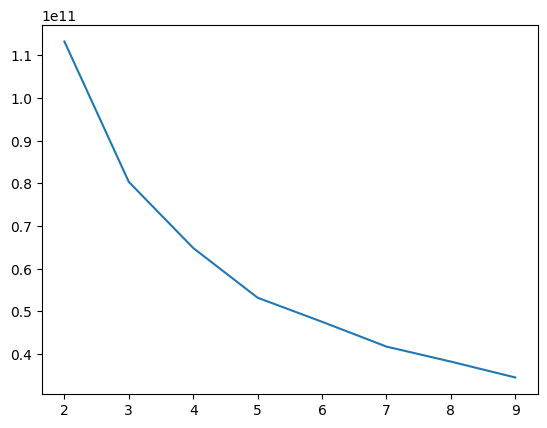

In [4]:
score = []
for k in range(2,10):
  model = KPrototypes(n_clusters=k)
  model.fit(df, categorical=[0,1])
  score.append(model.cost_)
plt.plot(range(2,10), score)

## TRAINING 

In [6]:
model = KPrototypes(n_clusters=3)
member = model.fit_predict(df, categorical=[0,1])

In [9]:
df_pred = df.copy()
df_pred["cluster"] = member
df_pred.head()

,Channel,Region,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen,cluster
0,2,3,12669,9656,7561,214,2674,1338,1
1,2,3,7057,9810,9568,1762,3293,1776,1
2,2,3,6353,8808,7684,2405,3516,7844,1
3,1,3,13265,1196,4221,6404,507,1788,1
4,2,3,22615,5410,7198,3915,1777,5185,0


## Analyze Cluster

In [10]:
num, cat = model.cluster_centroids_

In [11]:
df_cat = pd.DataFrame(cat, columns=df.columns[:2])
df_num = pd.DataFrame(num, columns=df.columns[2:])
df_cat.join(df_num)

,Channel,Region,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen
0,1,3,35941.400000,6044.45000,6288.616667,6713.966667,1039.666667,3049.466667
1,1,3,8253.469697,3824.60303,5280.454545,2572.660606,1773.057576,1137.496970
2,2,3,8000.040000,18511.42000,27573.900000,1996.680000,12407.360000,2252.020000


In [12]:
df.mean()

Channel                 1.322727
Region                  2.543182
Fresh               12000.297727
Milk                 5796.265909
Grocery              7951.277273
Frozen               3071.931818
Detergents_Paper     2881.493182
Delicassen           1524.870455
dtype: float64

# Kesimpulan Pengelompokan di Setiap Cluster

- cluster 0 : Tipikal customer yang belanja "Fresh Food"  
- cluster 1 : Tipikal customer yang "Hemat"  
- cluster 2 : Tipikal customer yang belanja "Susu, Sembako, Deterjen dan Produk Kertas lainnya"

How? Melakukan perbandingan dengan menganalisa Rata-rata dan Nilai Centroid